<a href="https://colab.research.google.com/github/laljithjohnson/my-colab-notebooks/blob/main/Lending_Club_Loan_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lending Club Loan Default Prediction

We will build this project step by step in one notebook. Run the cells from top to bottom after each update so you can inspect the output before we move to the next step.

## Step 1: Data Scan

This first step loads the Lending Club CSV, confirms the expected target column exists, checks the dataset shape, missing values, duplicate rows, target imbalance, purpose-level default rates, and strong numeric correlations. It also writes reusable summary CSV files into `reports/step_01_data_scan`.

### 1.1 Import Libraries and Configure the Data Source

 This cell imports the libraries we need for the scan and defines the dataset URL. The notebook reads `loan_data.csv` directly from GitHub so it can run from another machine, Colab, or any Jupyter environment with internet access.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/laljithjohnson/my-colab-notebooks/main/loan_data.csv"
OUTPUT_DIR = Path("reports/step_01_data_scan")
TARGET = "not.fully.paid"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 1.2 Load the Dataset

 This cell reads the CSV from GitHub into a pandas DataFrame and checks that the important columns for this project are present before we do any analysis.

In [2]:
df = pd.read_csv(DATA_URL)

required_columns = {"purpose", TARGET}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


### 1.3 Create Summary Tables

These helper functions build the data-quality and EDA summary tables. Keeping them in functions makes the notebook easier to update in later steps without repeating logic.

In [3]:
def build_column_summary(data: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "column": data.columns,
            "dtype": [str(data[col].dtype) for col in data.columns],
            "non_null": [int(data[col].notna().sum()) for col in data.columns],
            "missing": [int(data[col].isna().sum()) for col in data.columns],
            "missing_pct": [round(float(data[col].isna().mean() * 100), 2) for col in data.columns],
            "unique_values": [int(data[col].nunique(dropna=True)) for col in data.columns],
        }
    )


def build_numeric_summary(data: pd.DataFrame) -> pd.DataFrame:
    numeric = data.select_dtypes(include=[np.number])
    summary = numeric.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    return summary.round(4).rename_axis("column").reset_index()


def build_purpose_default_rates(data: pd.DataFrame) -> pd.DataFrame:
    rates = (
        data.groupby("purpose")[TARGET]
        .agg(total_loans="count", defaulted="sum", default_rate="mean")
        .sort_values("default_rate", ascending=False)
        .reset_index()
    )
    rates["default_rate"] = (rates["default_rate"] * 100).round(2)
    return rates


def build_correlation_pairs(data: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    numeric = data.select_dtypes(include=[np.number]).drop(columns=[TARGET], errors="ignore")
    corr = numeric.corr()
    rows = []
    columns = list(corr.columns)
    for left_index, left_col in enumerate(columns):
        for right_col in columns[left_index + 1 :]:
            value = float(corr.loc[left_col, right_col])
            if abs(value) >= threshold:
                rows.append(
                    {
                        "feature_1": left_col,
                        "feature_2": right_col,
                        "correlation": round(value, 4),
                    }
                )
    return pd.DataFrame(rows).sort_values("correlation", key=lambda s: s.abs(), ascending=False)

### 1.4 Save Summary Files

This cell writes the first checkpoint outputs. These files are useful if you want to inspect summaries outside the notebook or compare later preprocessing changes.

In [4]:
column_summary = build_column_summary(df)
numeric_summary = build_numeric_summary(df)
purpose_default_rates = build_purpose_default_rates(df)
correlation_pairs = build_correlation_pairs(df)

column_summary.to_csv(OUTPUT_DIR / "column_summary.csv", index=False)
numeric_summary.to_csv(OUTPUT_DIR / "numeric_summary.csv", index=False)
purpose_default_rates.to_csv(OUTPUT_DIR / "purpose_default_rates.csv", index=False)
correlation_pairs.to_csv(OUTPUT_DIR / "correlation_pairs.csv", index=False)

print(f"Summary files written to: {OUTPUT_DIR.resolve()}")

Summary files written to: /content/reports/step_01_data_scan


### 1.5 Review the Scan Results

This cell prints the main findings from Step 1 directly in the notebook: shape, duplicates, missing values, target imbalance, columns, and purpose-wise default rates.

In [5]:
target_counts = df[TARGET].value_counts().sort_index()
default_rate = df[TARGET].mean() * 100

print("STEP 1: DATA SCAN")
print("=" * 60)
print(f"Source URL: {DATA_URL}")
print(f"Rows x columns: {df.shape[0]:,} x {df.shape[1]:,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing values: {int(df.isna().sum().sum()):,}")

print("\nTarget distribution:")
for value, count in target_counts.items():
    label = "not fully paid / default" if value == 1 else "fully paid"
    print(f"  {value} ({label}): {count:,}")
print(f"  Default rate: {default_rate:.2f}%")

print("\nColumns:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}, unique={df[col].nunique(dropna=True):,}")

print("\nTop purpose default rates:")
for _, row in purpose_default_rates.iterrows():
    print(
        f"  {row['purpose']:<20} {row['default_rate']:>6.2f}% "
        f"({int(row['defaulted']):,}/{int(row['total_loans']):,})"
    )
print("=" * 60)

STEP 1: DATA SCAN
Source URL: https://raw.githubusercontent.com/laljithjohnson/my-colab-notebooks/main/loan_data.csv
Rows x columns: 9,578 x 14
Duplicate rows: 0
Missing values: 0

Target distribution:
  0 (fully paid): 8,045
  1 (not fully paid / default): 1,533
  Default rate: 16.01%

Columns:
  - credit.policy: int64, unique=2
  - purpose: object, unique=7
  - int.rate: float64, unique=249
  - installment: float64, unique=4,788
  - log.annual.inc: float64, unique=1,987
  - dti: float64, unique=2,529
  - fico: int64, unique=44
  - days.with.cr.line: float64, unique=2,687
  - revol.bal: int64, unique=7,869
  - revol.util: float64, unique=1,035
  - inq.last.6mths: int64, unique=28
  - delinq.2yrs: int64, unique=11
  - pub.rec: int64, unique=6
  - not.fully.paid: int64, unique=2

Top purpose default rates:
  small_business        27.79% (172/619)
  educational           20.12% (69/343)
  home_improvement      17.01% (107/629)
  all_other             16.60% (387/2,331)
  debt_consolidati

### 1.6 Inspect Generated Tables

Run these display cells when you want to inspect the saved summary tables in notebook form.

In [6]:
column_summary

,column,dtype,non_null,missing,missing_pct,unique_values
0,credit.policy,int64,9578,0,0.0,2
1,purpose,object,9578,0,0.0,7
2,int.rate,float64,9578,0,0.0,249
3,installment,float64,9578,0,0.0,4788
4,log.annual.inc,float64,9578,0,0.0,1987
5,dti,float64,9578,0,0.0,2529
6,fico,int64,9578,0,0.0,44
7,days.with.cr.line,float64,9578,0,0.0,2687
8,revol.bal,int64,9578,0,0.0,7869
9,revol.util,float64,9578,0,0.0,1035


In [7]:
numeric_summary

,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,credit.policy,9578.0,0.8050,0.3962,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000000e+00
1,int.rate,9578.0,0.1226,0.0268,0.0600,0.0737,0.0774,0.1039,0.1221,0.1407,0.1670,0.1886,2.164000e-01
2,installment,9578.0,319.0894,207.0713,15.6700,33.1009,65.5595,163.7700,268.9500,432.7625,756.2655,870.3900,9.401400e+02
3,log.annual.inc,9578.0,10.9321,0.6148,7.5475,9.3927,9.9179,10.5584,10.9289,11.2913,11.9184,12.4846,1.452840e+01
4,dti,9578.0,12.6067,6.8840,0.0000,0.0700,1.2700,7.2125,12.6650,17.9500,23.6500,26.2423,2.996000e+01
5,fico,9578.0,710.8463,37.9705,612.0000,642.0000,657.0000,682.0000,707.0000,737.0000,782.0000,802.0000,8.270000e+02
6,days.with.cr.line,9578.0,4560.7672,2496.9304,178.9583,570.0321,1320.0417,2820.0000,4139.9583,5730.0000,9329.9583,12930.0096,1.763996e+04
7,revol.bal,9578.0,16913.9639,33756.1896,0.0000,0.0000,127.7000,3187.0000,8596.0000,18249.5000,57654.3000,156762.5800,1.207359e+06
8,revol.util,9578.0,46.7992,29.0144,0.0000,0.0000,1.1000,22.6000,46.3000,70.9000,94.0000,98.9230,1.190000e+02
9,inq.last.6mths,9578.0,1.5775,2.2002,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,5.0000,9.0000,3.300000e+01


In [8]:
purpose_default_rates

,purpose,total_loans,defaulted,default_rate
0,small_business,619,172,27.79
1,educational,343,69,20.12
2,home_improvement,629,107,17.01
3,all_other,2331,387,16.60
4,debt_consolidation,3957,603,15.24
5,credit_card,1262,146,11.57
6,major_purchase,437,49,11.21


In [9]:
correlation_pairs

,feature_1,feature_2,correlation
1,int.rate,fico,-0.7148
2,fico,revol.util,-0.5413
0,credit.policy,inq.last.6mths,-0.5355


## Step 2: Exploratory Data Analysis

In this step, we visually explore the dataset before preprocessing and modeling. The goal is to understand class imbalance, how loan purpose relates to default, how numeric features are distributed, and which numeric features move differently for fully paid versus not fully paid loans.

### 2.1 Configure Plotting

This cell imports plotting tools, creates a folder for EDA images, and sets a consistent chart style. The `%matplotlib inline` command is safe in notebooks and makes charts display directly below each code cell.

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt

FIGURE_DIR = Path("reports/step_02_eda")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 2.2 Visualize Target Imbalance

This chart shows how many loans were fully paid versus not fully paid. Because the default class is much smaller, later model evaluation should use more than accuracy, such as recall, precision, F1-score, ROC-AUC, and a confusion matrix.

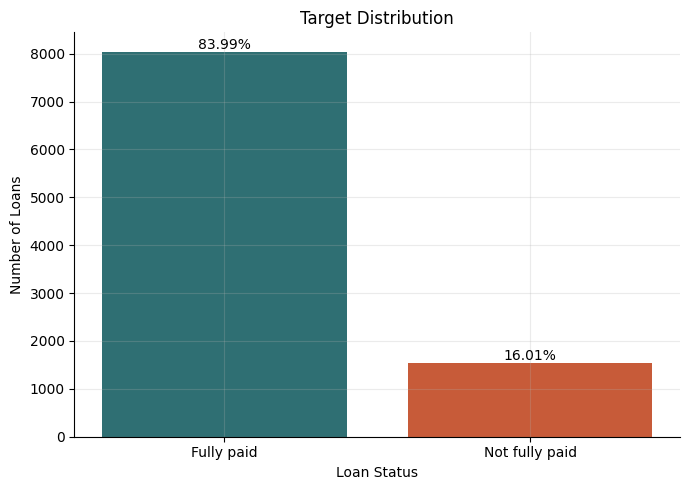

,loan_status,count,percentage
0,Fully paid,8045,83.99
1,Not fully paid,1533,16.01


In [11]:
target_summary = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Fully paid", 1: "Not fully paid"})
    .rename_axis("loan_status")
    .reset_index(name="count")
)
target_summary["percentage"] = (target_summary["count"] / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(target_summary["loan_status"], target_summary["count"], color=["#2F6F73", "#C75B39"])
ax.set_title("Target Distribution")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Number of Loans")

for bar, percentage in zip(bars, target_summary["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

target_summary

### 2.3 Compare Loan Purpose Counts and Default Rates

These charts show two related views of `purpose`: how common each loan purpose is, and what percentage of loans defaulted within each purpose. This helps separate volume from risk.

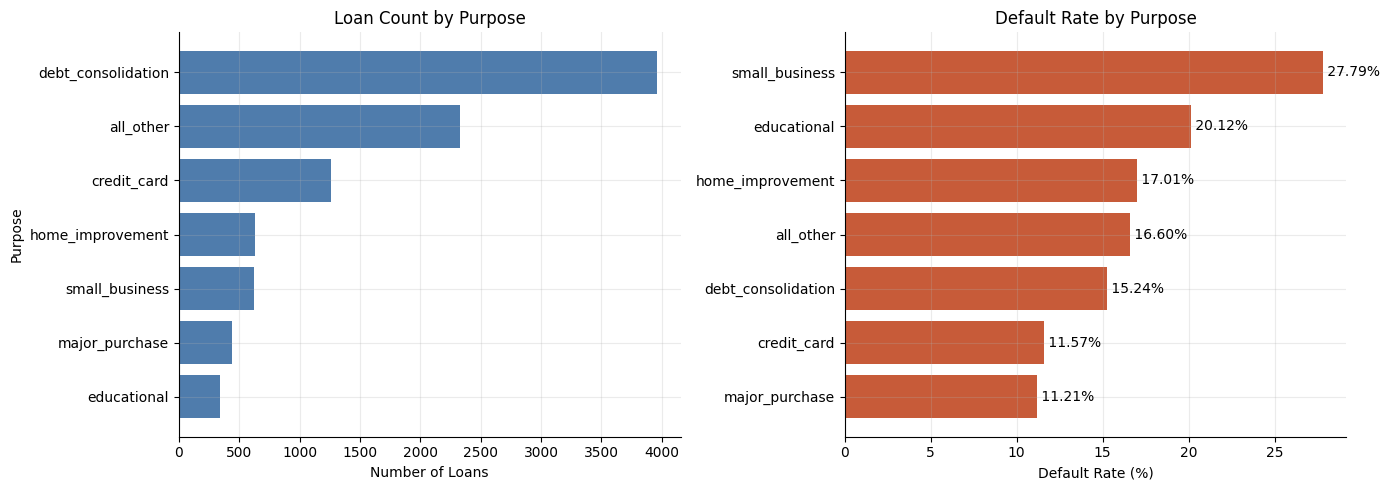

,purpose,total_loans,defaulted,default_rate
0,small_business,619,172,27.79
1,educational,343,69,20.12
2,home_improvement,629,107,17.01
3,all_other,2331,387,16.60
4,debt_consolidation,3957,603,15.24
5,credit_card,1262,146,11.57
6,major_purchase,437,49,11.21


In [12]:
purpose_counts = df["purpose"].value_counts().sort_values(ascending=True)
purpose_rates = purpose_default_rates.sort_values("default_rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(purpose_counts.index, purpose_counts.values, color="#4F7CAC")
axes[0].set_title("Loan Count by Purpose")
axes[0].set_xlabel("Number of Loans")
axes[0].set_ylabel("Purpose")

axes[1].barh(purpose_rates["purpose"], purpose_rates["default_rate"], color="#C75B39")
axes[1].set_title("Default Rate by Purpose")
axes[1].set_xlabel("Default Rate (%)")
axes[1].set_ylabel("")

for value, label in zip(purpose_rates["default_rate"], purpose_rates["purpose"]):
    axes[1].text(value, label, f" {value:.2f}%", va="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "purpose_counts_and_default_rates.png", dpi=150, bbox_inches="tight")
plt.show()

purpose_default_rates

### 2.4 Inspect Numeric Feature Distributions

This grid shows histograms for all numeric columns except the target. Skewed features and extreme values are important because neural networks often benefit from scaling and, for heavily skewed variables, transformations such as log scaling or clipping.

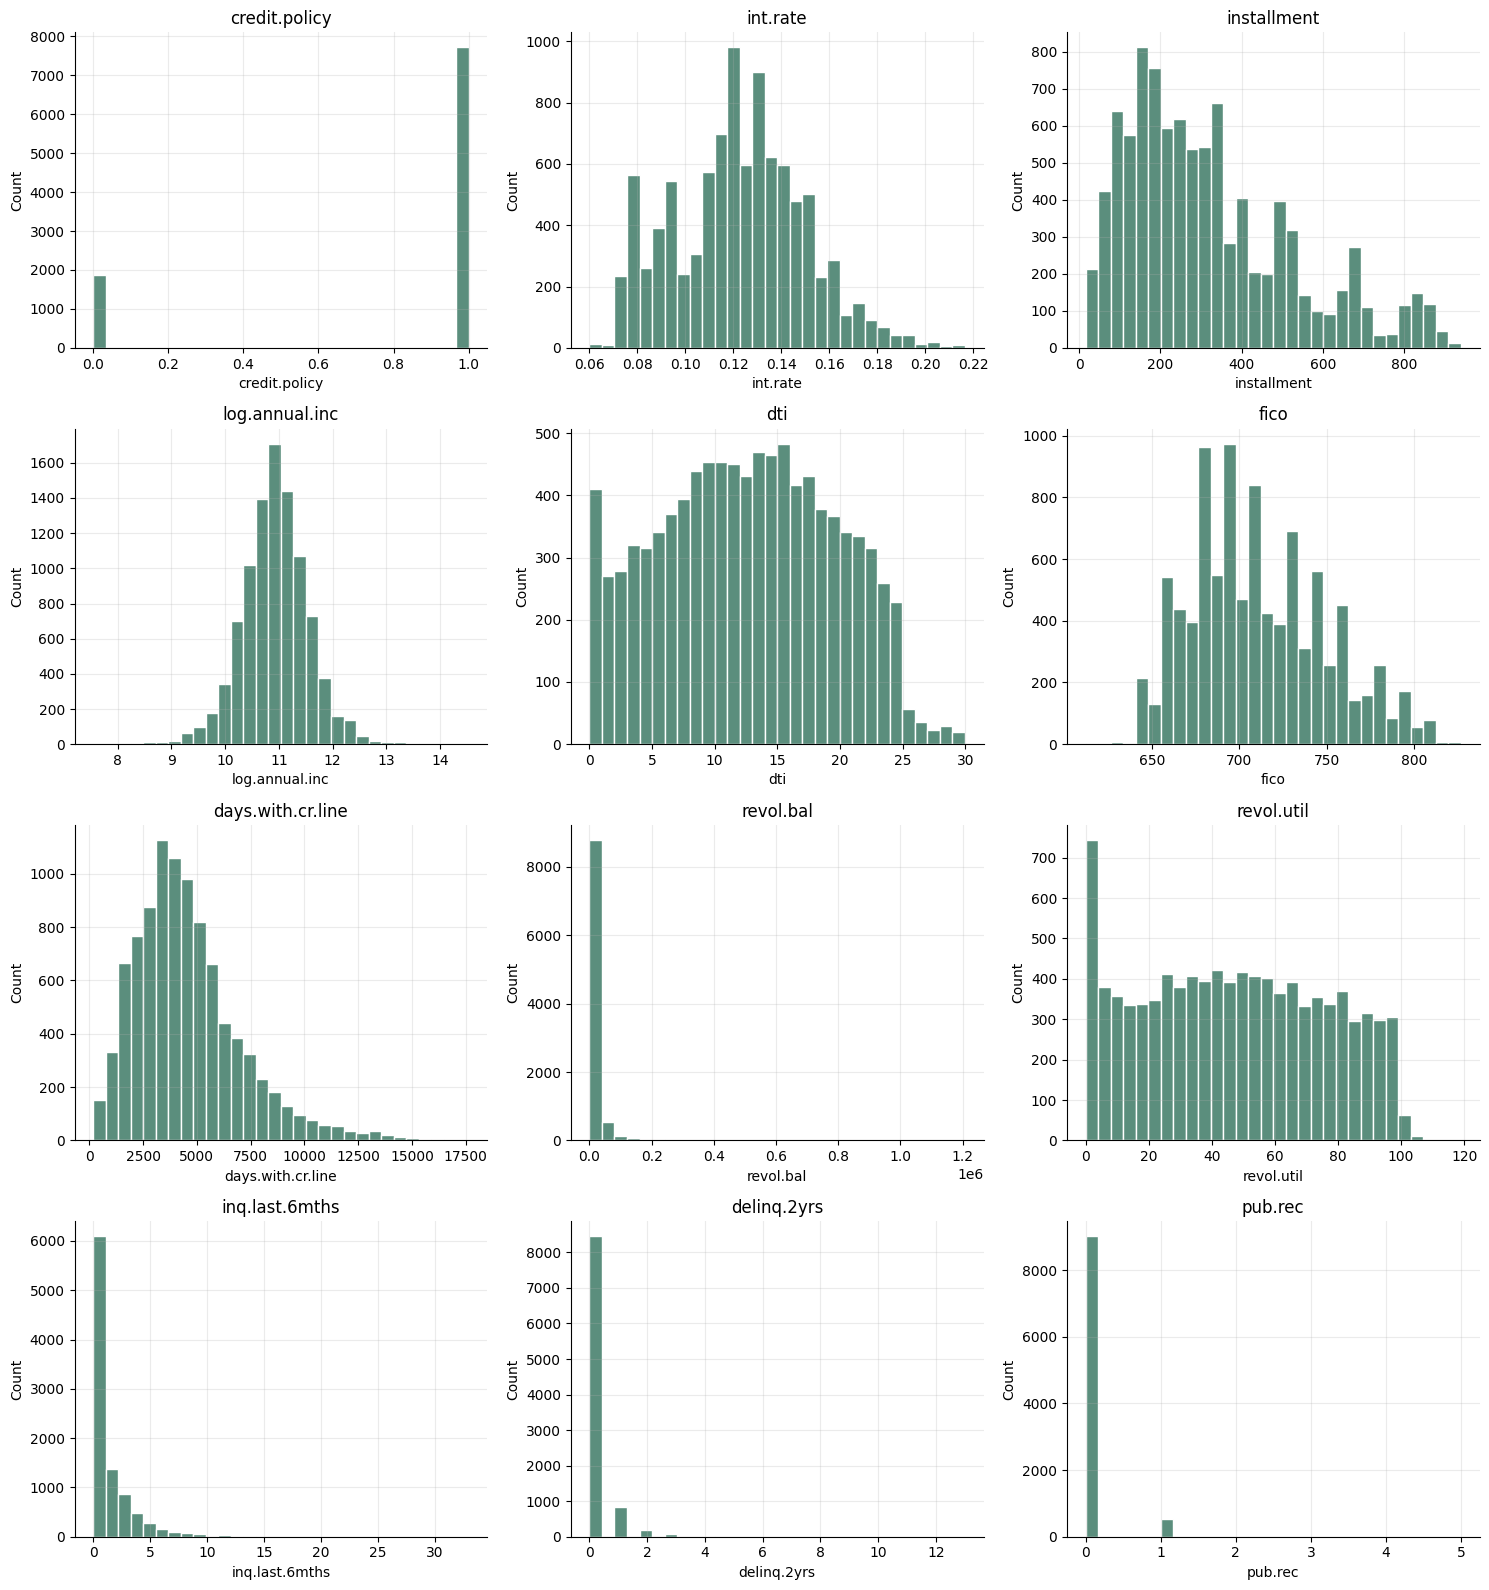

In [13]:
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[TARGET]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for index, feature in enumerate(numeric_features):
    axes[index].hist(df[feature], bins=30, color="#5B8E7D", edgecolor="white")
    axes[index].set_title(feature)
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Count")

for index in range(len(numeric_features), len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "numeric_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5 Compare Numeric Features by Target Class

This table compares the mean value of each numeric feature for fully paid and not fully paid loans. The `difference` column is calculated as `not fully paid mean - fully paid mean`, which gives a quick directional view of which features are higher or lower among defaults.

In [14]:
target_mean_comparison = df.groupby(TARGET)[numeric_features].mean().T

target_mean_comparison = target_mean_comparison.rename(columns={0: "fully_paid_mean", 1: "not_fully_paid_mean"})
target_mean_comparison["difference"] = (
    target_mean_comparison["not_fully_paid_mean"] - target_mean_comparison["fully_paid_mean"]
)
target_mean_comparison["abs_difference"] = target_mean_comparison["difference"].abs()
target_mean_comparison = target_mean_comparison.sort_values("abs_difference", ascending=False).round(4)

target_mean_comparison.to_csv(FIGURE_DIR / "target_mean_comparison.csv")
target_mean_comparison

not.fully.paid,fully_paid_mean,not_fully_paid_mean,difference,abs_difference
revol.bal,16122.7244,21066.2935,4943.5691,4943.5691
days.with.cr.line,4592.6326,4393.5413,-199.0914,199.0914
installment,314.5741,342.7851,28.2110,28.2110
fico,713.3269,697.8284,-15.4985,15.4985
revol.util,45.7596,52.2551,6.4955,6.4955
inq.last.6mths,1.4339,2.3307,0.8968,0.8968
dti,12.4944,13.1958,0.7014,0.7014
credit.policy,0.8323,0.6614,-0.1709,0.1709
log.annual.inc,10.9411,10.8850,-0.0561,0.0561
pub.rec,0.0566,0.0913,0.0348,0.0348


### 2.6 Plot Correlations Between Numeric Features

This heatmap shows pairwise correlations among numeric variables. Strong correlations can signal redundant features, which matters for feature engineering and model interpretation.

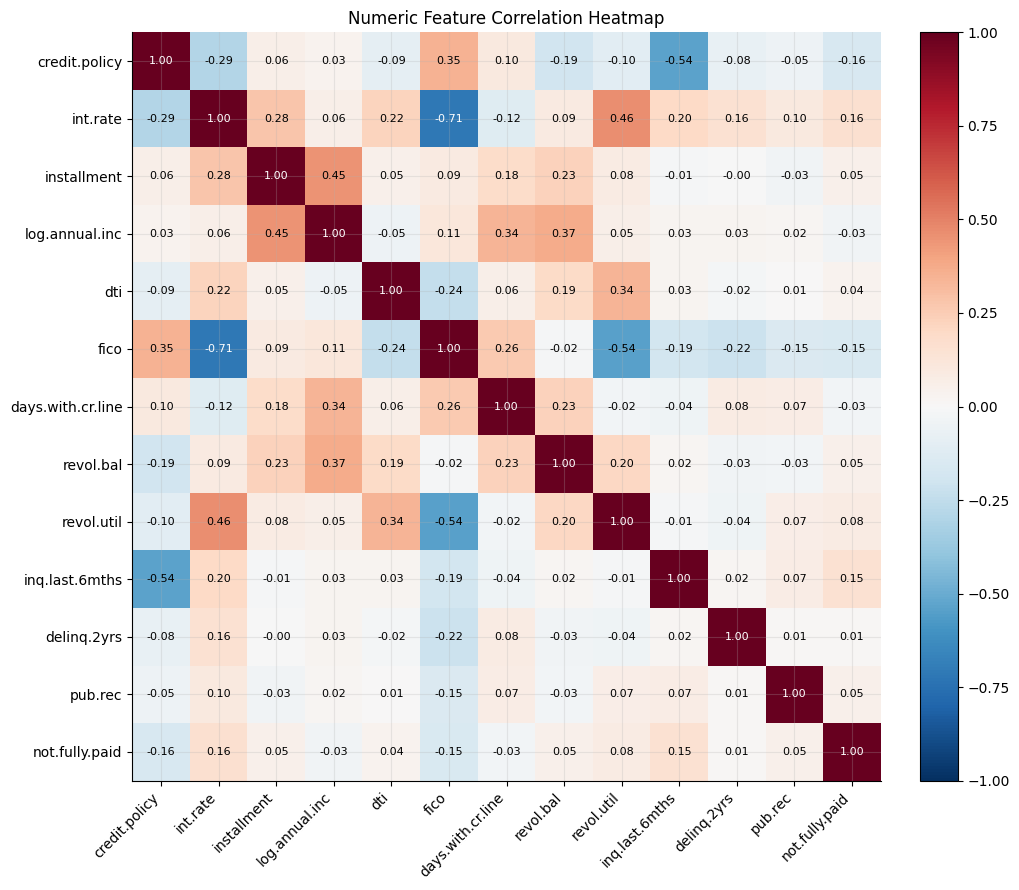

In [15]:
corr = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Numeric Feature Correlation Heatmap")

for row in range(len(corr.columns)):
    for col in range(len(corr.columns)):
        value = corr.iloc[row, col]
        text_color = "white" if abs(value) > 0.6 else "black"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "numeric_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.7 Step 2 Notes

After running the Step 2 cells, inspect the charts and tables. The main things to note are the class imbalance, high-risk loan purposes, skewed numeric variables, possible outliers, and correlated feature pairs. We will use these observations in the next step when we transform categorical values and prepare features for modeling.

## Step 3: Feature Engineering

In this step, we convert the raw dataset into a model-ready feature table. Before changing the data, we use a short questionnaire to make the main modeling choices explicit. The default choices are conservative and suitable for a first deep-learning baseline.

### 3.1 Feature Engineering Questionnaire

Review these choices before running the Step 3 code cells. The next cell turns these answers into editable Python variables.

| Question | Default answer | Why this default is reasonable |
| --- | --- | --- |
| Should the target column be separated before feature changes? | Yes | Prevents accidental target leakage. |
| How should `purpose` be encoded? | One-hot encoding | It is nominal, not ordinal, so integer labels would create a fake ranking. |
| Should we engineer readable financial features? | Yes | `annual_inc`, `credit_line_years`, and `log_revol_bal` make the feature set easier to interpret and often easier to model. |
| Should extreme numeric values be capped? | Yes, only selected skewed columns | Reduces the effect of extreme outliers without deleting rows. |
| Should correlated features be dropped automatically? | No, review first | Correlation does not always mean a feature is useless. We will create a review table, then choose drops deliberately. |
| Should raw source columns be kept after creating transformed versions? | Mixed | Keep useful originals, but drop `days.with.cr.line` after making `credit_line_years`; keep `log.annual.inc` because it is already a stable transformed income feature. |
| Should scaling happen now? | No | Scaling belongs after train-test split to avoid data leakage. We will do it in the modeling preparation step. |
| Should class imbalance be handled now? | No | We first preserve the real distribution, then handle imbalance during model training/evaluation. |

### 3.2 Set Feature Engineering Decisions

This cell stores the questionnaire answers as configuration variables. You can edit these values before running the rest of Step 3 if you want to test a different strategy.

In [16]:
FEATURE_DIR = Path("reports/step_03_feature_engineering")
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

ENCODE_PURPOSE = True
ADD_ENGINEERED_FEATURES = True
CAP_OUTLIERS = True
DROP_HIGH_CORRELATION_FEATURES = False

OUTLIER_CAP_COLUMNS = ["revol.bal", "inq.last.6mths", "revol.util"]
OUTLIER_LOWER_QUANTILE = 0.01
OUTLIER_UPPER_QUANTILE = 0.99

# We drop this raw duration column after converting it to years.
MANUAL_DROP_COLUMNS = ["days.with.cr.line"]

# Keep this empty for now. Add feature names here only after reviewing correlation and model behavior.
HIGH_CORRELATION_DROP_COLUMNS = []

### 3.3 Separate Target and Start a Feature Copy

This cell separates `y`, the prediction target, from `features`, the table we will transform. Keeping the target separate is the simplest guard against target leakage.

In [17]:
y = df[TARGET].copy()
features = df.drop(columns=[TARGET]).copy()

print(f"Feature table shape before engineering: {features.shape}")
print(f"Target shape: {y.shape}")
features.head()

Feature table shape before engineering: (9578, 13)
Target shape: (9578,)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0


### 3.4 Add Engineered Numeric Features

This cell creates interpretable numeric features from existing columns. We convert logged annual income back to approximate annual income, convert credit-line age from days to years, and log-transform revolving balance to reduce skew.

In [18]:
if ADD_ENGINEERED_FEATURES:
    features["annual_inc"] = np.exp(features["log.annual.inc"])
    features["credit_line_years"] = features["days.with.cr.line"] / 365.25
    features["log_revol_bal"] = np.log1p(features["revol.bal"])

engineered_columns = [col for col in ["annual_inc", "credit_line_years", "log_revol_bal"] if col in features.columns]
print(f"Engineered columns added: {engineered_columns}")
features[engineered_columns].head()

Engineered columns added: ['annual_inc', 'credit_line_years', 'log_revol_bal']


,annual_inc,credit_line_years,log_revol_bal
0,85000.000385,15.441364,10.270039
1,65000.000073,7.556468,10.422995
2,31999.999943,12.895277,8.163941
3,85000.000385,7.392083,10.424303
4,80799.999636,11.132101,8.464003


### 3.5 Cap Selected Outliers

This cell caps only selected skewed numeric columns at the 1st and 99th percentiles. The original columns are replaced with capped versions, and the cap values are saved so the transformation is auditable.

In [19]:
outlier_caps = []

if CAP_OUTLIERS:
    for column in OUTLIER_CAP_COLUMNS:
        lower_value = features[column].quantile(OUTLIER_LOWER_QUANTILE)
        upper_value = features[column].quantile(OUTLIER_UPPER_QUANTILE)
        before_min = features[column].min()
        before_max = features[column].max()
        features[column] = features[column].clip(lower=lower_value, upper=upper_value)
        outlier_caps.append(
            {
                "column": column,
                "lower_quantile": OUTLIER_LOWER_QUANTILE,
                "upper_quantile": OUTLIER_UPPER_QUANTILE,
                "lower_value": lower_value,
                "upper_value": upper_value,
                "before_min": before_min,
                "before_max": before_max,
                "after_min": features[column].min(),
                "after_max": features[column].max(),
            }
        )

outlier_caps_df = pd.DataFrame(outlier_caps)
outlier_caps_df.to_csv(FEATURE_DIR / "outlier_caps.csv", index=False)
outlier_caps_df

,column,lower_quantile,upper_quantile,lower_value,upper_value,before_min,before_max,after_min,after_max
0,revol.bal,0.01,0.99,0.0,156762.580,0.0,1207359.0,0.0,156762.580
1,inq.last.6mths,0.01,0.99,0.0,9.000,0.0,33.0,0.0,9.000
2,revol.util,0.01,0.99,0.0,98.923,0.0,119.0,0.0,98.923


### 3.6 Drop Manually Selected Raw Columns

This cell removes raw columns that have been replaced by clearer engineered versions. For now, we drop `days.with.cr.line` because `credit_line_years` is easier to interpret.

In [20]:
columns_to_drop = [col for col in MANUAL_DROP_COLUMNS if col in features.columns]
features = features.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"Feature table shape after manual drops: {features.shape}")

Dropped columns: ['days.with.cr.line']
Feature table shape after manual drops: (9578, 15)


### 3.7 Review High Correlations Before Dropping

This cell recalculates correlations after feature engineering and lists strongly correlated numeric feature pairs. We do not drop them automatically by default; this table is for review and documentation.

In [21]:
def find_high_correlation_pairs(data: pd.DataFrame, threshold: float = 0.70) -> pd.DataFrame:
    numeric_data = data.select_dtypes(include=[np.number])
    corr_matrix = numeric_data.corr()
    rows = []
    columns = list(corr_matrix.columns)

    for left_index, left_column in enumerate(columns):
        for right_column in columns[left_index + 1 :]:
            correlation = corr_matrix.loc[left_column, right_column]
            if abs(correlation) >= threshold:
                rows.append(
                    {
                        "feature_1": left_column,
                        "feature_2": right_column,
                        "correlation": round(float(correlation), 4),
                    }
                )

    return pd.DataFrame(rows).sort_values("correlation", key=lambda col: col.abs(), ascending=False)


high_correlation_pairs = find_high_correlation_pairs(features, threshold=0.70)
high_correlation_pairs.to_csv(FEATURE_DIR / "high_correlation_pairs.csv", index=False)
high_correlation_pairs

,feature_1,feature_2,correlation
1,log.annual.inc,annual_inc,0.7769
0,int.rate,fico,-0.7148


### 3.8 Optionally Drop High-Correlation Features

This cell applies any feature drops you decide to list in `HIGH_CORRELATION_DROP_COLUMNS`. The default is an empty list, so no additional columns are removed yet.

In [22]:
if DROP_HIGH_CORRELATION_FEATURES:
    high_corr_drops = [col for col in HIGH_CORRELATION_DROP_COLUMNS if col in features.columns]
    features = features.drop(columns=high_corr_drops)
else:
    high_corr_drops = []

print(f"High-correlation columns dropped: {high_corr_drops}")
print(f"Feature table shape after correlation review: {features.shape}")

High-correlation columns dropped: []
Feature table shape after correlation review: (9578, 15)


### 3.9 One-Hot Encode Categorical Features

This cell converts `purpose` into one-hot encoded columns. We keep all purpose categories so each category has a clear feature column, which works well for neural-network input features.

In [23]:
if ENCODE_PURPOSE:
    model_features = pd.get_dummies(features, columns=["purpose"], prefix="purpose", drop_first=False, dtype=int)
else:
    model_features = features.copy()

print(f"Model feature table shape: {model_features.shape}")
model_features.head()

Model feature table shape: (9578, 21)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,...,annual_inc,credit_line_years,log_revol_bal,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,28854.0,52.1,0,0,...,85000.000385,15.441364,10.270039,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,33623.0,76.7,0,0,...,65000.000073,7.556468,10.422995,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,3511.0,25.6,1,0,...,31999.999943,12.895277,8.163941,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,33667.0,73.2,1,0,...,85000.000385,7.392083,10.424303,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4740.0,39.5,0,1,...,80799.999636,11.132101,8.464003,0,1,0,0,0,0,0


### 3.10 Save the Feature-Engineered Dataset

This cell combines the engineered features with the target and saves the result. We also save a metadata table that lists each model feature and its data type.

In [24]:
model_dataset = model_features.copy()
model_dataset[TARGET] = y.values

feature_metadata = pd.DataFrame(
    {
        "feature": model_features.columns,
        "dtype": [str(model_features[col].dtype) for col in model_features.columns],
        "missing_values": [int(model_features[col].isna().sum()) for col in model_features.columns],
        "unique_values": [int(model_features[col].nunique(dropna=True)) for col in model_features.columns],
    }
)

model_dataset.to_csv(FEATURE_DIR / "loan_data_feature_engineered.csv", index=False)
feature_metadata.to_csv(FEATURE_DIR / "feature_metadata.csv", index=False)

print(f"Saved feature-engineered dataset to: {(FEATURE_DIR / 'loan_data_feature_engineered.csv').resolve()}")
print(f"Rows x columns including target: {model_dataset.shape[0]:,} x {model_dataset.shape[1]:,}")
feature_metadata

Saved feature-engineered dataset to: /content/reports/step_03_feature_engineering/loan_data_feature_engineered.csv
Rows x columns including target: 9,578 x 22


,feature,dtype,missing_values,unique_values
0,credit.policy,int64,0,2
1,int.rate,float64,0,249
2,installment,float64,0,4788
3,log.annual.inc,float64,0,1987
4,dti,float64,0,2529
5,fico,int64,0,44
6,revol.bal,float64,0,7776
7,revol.util,float64,0,1002
8,inq.last.6mths,int64,0,10
9,delinq.2yrs,int64,0,11


### 3.11 Step 3 Checklist

Before moving to the next step, check that the engineered dataset has no missing values, the target is still unchanged, and the number of rows still matches the raw data. If those checks pass, we are ready for train-test splitting and scaling.

In [25]:
checks = {
    "raw_rows": len(df),
    "engineered_rows": len(model_dataset),
    "target_matches_original": bool(model_dataset[TARGET].equals(df[TARGET])),
    "missing_values_in_engineered_data": int(model_dataset.isna().sum().sum()),
    "feature_columns_before_target": model_dataset.shape[1] - 1,
}

checks

{'raw_rows': 9578,
 'engineered_rows': 9578,
 'target_matches_original': True,
 'missing_values_in_engineered_data': 0,
 'feature_columns_before_target': 21}

## Step 4: Train-Test Split and Scaling

In this step, we prepare the feature-engineered data for modeling. We split the data into training and testing sets, preserve the target class ratio with stratification, scale numeric inputs using only the training data, and save the prepared arrays for the modeling step.

### 4.1 Modeling Preparation Questionnaire

Review these choices before running the Step 4 code cells. These defaults are good for a first supervised-learning baseline.

| Question | Default answer | Why this default is reasonable |
| --- | --- | --- |
| What should be predicted? | `not.fully.paid` | This is the project target: 1 means the loan was not fully paid. |
| How much data should be held out for testing? | 20% | Keeps enough data for training while preserving a meaningful final test set. |
| Should the split be stratified? | Yes | The target is imbalanced, so train and test should keep similar class ratios. |
| Should scaling happen after the split? | Yes | Fitting the scaler before the split would leak information from the test set. |
| Which scaler should be used first? | `StandardScaler` | Neural networks usually train better when numeric inputs are centered and scaled. |
| Should the target be scaled? | No | Binary classification targets should remain 0/1. |
| Should we save prepared outputs? | Yes | This creates a stable checkpoint for the next modeling step. |

### 4.2 Import Train-Test and Scaling Tools

This cell imports the scikit-learn utilities needed for splitting and scaling. If you are running in Colab, these are normally available by default.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 4.3 Set Split and Scaling Configuration

This cell stores the train-test split settings. `RANDOM_STATE` makes the split reproducible so your results do not change every time you rerun the notebook.

In [27]:
PREP_DIR = Path("reports/step_04_model_preparation")
PREP_DIR.mkdir(parents=True, exist_ok=True)

TEST_SIZE = 0.20
RANDOM_STATE = 42
STRATIFY_TARGET = True

### 4.4 Separate Model Inputs and Target

This cell creates `X` for model inputs and `y_model` for the target. At this point all model input columns should already be numeric because Step 3 one-hot encoded `purpose`.

In [28]:
X = model_dataset.drop(columns=[TARGET]).copy()
y_model = model_dataset[TARGET].copy()

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(f"Non-numeric model columns found: {non_numeric_columns}")

print(f"X shape: {X.shape}")
print(f"y shape: {y_model.shape}")
X.head()

X shape: (9578, 21)
y shape: (9578,)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,...,annual_inc,credit_line_years,log_revol_bal,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,28854.0,52.1,0,0,...,85000.000385,15.441364,10.270039,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,33623.0,76.7,0,0,...,65000.000073,7.556468,10.422995,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,3511.0,25.6,1,0,...,31999.999943,12.895277,8.163941,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,33667.0,73.2,1,0,...,85000.000385,7.392083,10.424303,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4740.0,39.5,0,1,...,80799.999636,11.132101,8.464003,0,1,0,0,0,0,0


### 4.5 Create a Stratified Train-Test Split

This cell splits the data into training and testing sets. Stratification keeps the default rate similar in both sets, which is important because the default class is relatively small.

In [29]:
stratify_values = y_model if STRATIFY_TARGET else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_values,
)

split_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "default_count": [int(y_train.sum()), int(y_test.sum())],
        "default_rate_pct": [round(float(y_train.mean() * 100), 2), round(float(y_test.mean() * 100), 2)],
    }
)

split_summary

,dataset,rows,default_count,default_rate_pct
0,train,7662,1226,16.00
1,test,1916,307,16.02


### 4.6 Fit the Scaler on Training Data Only

This cell fits `StandardScaler` on `X_train` only, then transforms both train and test inputs. This prevents test-set leakage while giving the neural network scaled numeric inputs.

In [30]:
scaler = StandardScaler()
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X.columns, index=X_test.index)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape: {X_test_scaled.shape}")
X_train_scaled.head()

Scaled train shape: (7662, 21)
Scaled test shape: (1916, 21)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,...,annual_inc,credit_line_years,log_revol_bal,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
6381,0.491542,0.744534,1.109194,0.696658,0.012171,-0.629324,0.026233,0.953291,-0.275469,1.591971,...,0.308025,0.275685,0.510377,-0.572628,2.584058,-0.834196,-0.194033,-0.261668,-0.219765,-0.265913
7589,0.491542,-1.779946,-0.795226,0.174696,0.017975,0.689102,-0.180747,-0.150348,-0.800373,-0.302667,...,-0.103751,0.234302,0.346771,-0.572628,2.584058,-0.834196,-0.194033,-0.261668,-0.219765,-0.265913
465,0.491542,-0.912273,-0.889878,-0.252212,-0.101001,0.161732,0.145651,-0.339445,-0.800373,1.591971,...,-0.355003,0.699294,0.583595,-0.572628,-0.386988,1.198759,-0.194033,-0.261668,-0.219765,-0.265913
5343,0.491542,0.486476,0.096296,1.097154,0.506940,-0.629324,-0.598361,0.086883,-0.275469,-0.302667,...,0.726779,-0.493588,-0.571997,1.746334,-0.386988,-0.834196,-0.194033,-0.261668,-0.219765,-0.265913
8016,-2.034412,0.318178,0.576044,1.172312,-0.333151,-1.288536,-0.663386,-1.614991,1.299244,-0.302667,...,0.817509,-1.555593,-3.950224,-0.572628,-0.386988,1.198759,-0.194033,-0.261668,-0.219765,-0.265913


### 4.7 Confirm Scaling Behavior

This cell checks that the training features are approximately centered around 0 with standard deviation around 1. The test set is transformed using the train-fitted scaler, so its means and standard deviations do not need to be exactly 0 and 1.

In [31]:
scaling_check = pd.DataFrame(
    {
        "train_mean": X_train_scaled.mean().round(4),
        "train_std": X_train_scaled.std(ddof=0).round(4),
        "test_mean": X_test_scaled.mean().round(4),
        "test_std": X_test_scaled.std(ddof=0).round(4),
    }
)

scaling_check.to_csv(PREP_DIR / "scaling_check.csv")
scaling_check.head(20)

,train_mean,train_std,test_mean,test_std
credit.policy,0.0,1.0,-0.0055,1.0042
int.rate,-0.0,1.0,-0.0098,1.0199
installment,-0.0,1.0,-0.0172,1.0123
log.annual.inc,-0.0,1.0,-0.0150,1.0016
dti,0.0,1.0,-0.0141,0.9937
fico,-0.0,1.0,-0.0027,1.0059
revol.bal,0.0,1.0,-0.0412,0.9181
revol.util,0.0,1.0,-0.0329,0.9811
inq.last.6mths,-0.0,1.0,0.0116,1.0022
delinq.2yrs,-0.0,1.0,0.0375,1.1632


### 4.8 Save Prepared Modeling Files

This cell saves train/test inputs, train/test targets, feature names, split summary, and scaler parameters. These files make Step 4 a clean checkpoint before model building.

In [32]:
X_train_scaled.to_csv(PREP_DIR / "X_train_scaled.csv", index=False)
X_test_scaled.to_csv(PREP_DIR / "X_test_scaled.csv", index=False)
y_train.to_frame(TARGET).to_csv(PREP_DIR / "y_train.csv", index=False)
y_test.to_frame(TARGET).to_csv(PREP_DIR / "y_test.csv", index=False)
split_summary.to_csv(PREP_DIR / "split_summary.csv", index=False)

feature_names = pd.DataFrame({"feature": X.columns})
feature_names.to_csv(PREP_DIR / "feature_names.csv", index=False)

scaler_parameters = pd.DataFrame(
    {
        "feature": X.columns,
        "mean": scaler.mean_,
        "scale": scaler.scale_,
    }
)
scaler_parameters.to_csv(PREP_DIR / "scaler_parameters.csv", index=False)

print(f"Prepared modeling files saved to: {PREP_DIR.resolve()}")
print(f"Training rows: {len(X_train_scaled):,}")
print(f"Testing rows: {len(X_test_scaled):,}")

Prepared modeling files saved to: /content/reports/step_04_model_preparation
Training rows: 7,662
Testing rows: 1,916


### 4.9 Step 4 Checklist

Before moving to modeling, confirm that the train and test default rates are close, all model inputs are numeric, there are no missing values, and the scaled training features look centered. If these checks pass, the next step is building the first neural-network baseline.

In [33]:
prep_checks = {
    "train_rows": len(X_train_scaled),
    "test_rows": len(X_test_scaled),
    "total_rows_match_original": len(X_train_scaled) + len(X_test_scaled) == len(model_dataset),
    "train_missing_values": int(X_train_scaled.isna().sum().sum()),
    "test_missing_values": int(X_test_scaled.isna().sum().sum()),
    "train_default_rate_pct": round(float(y_train.mean() * 100), 2),
    "test_default_rate_pct": round(float(y_test.mean() * 100), 2),
    "all_features_numeric": len(non_numeric_columns) == 0,
}

prep_checks

{'train_rows': 7662,
 'test_rows': 1916,
 'total_rows_match_original': True,
 'train_missing_values': 0,
 'test_missing_values': 0,
 'train_default_rate_pct': 16.0,
 'test_default_rate_pct': 16.02,
 'all_features_numeric': True}

## Step 5: Deep Neural Network Baseline

In this step, we build the first deep neural network for predicting `not.fully.paid`. This is the first true modeling checkpoint. We will keep the architecture simple but strong enough to learn non-linear patterns, use class weights because the target is imbalanced, and evaluate the model with metrics that are more informative than accuracy alone.

### 5.1 Deep Learning Modeling Questionnaire

Review these choices before running the Step 5 code cells.

| Question | Default answer | Why this default is reasonable |
| --- | --- | --- |
| What model should we build? | A deeper feed-forward neural network with layers `6 -> 12 -> 24 -> 64 -> 128 -> 256 -> 128 -> 64 -> 32 -> 8 -> 4 -> 1` | This follows the requested deep architecture while staying suitable for tabular data. |
| What business error matters most? | False negatives for default loans | A false negative means the model predicts a real defaulter as safe, which is the risky loan-approval case. |
| Which class metric matters most? | Recall for class `1` | Higher default recall means fewer actual defaulters are missed. |
| Should we use class weights? | Yes, with extra weight on class `1` | The default class is the minority and is more costly to miss. |
| What loss function should we use? | Binary cross-entropy | This is the standard loss for binary classification. |
| What final activation should we use? | Sigmoid | It outputs a default probability between 0 and 1. |
| How do we improve stability? | Batch normalization, dropout, L2 regularization, gradient clipping, early stopping, and learning-rate reduction | These reduce overfitting and make training less jumpy. |
| Should threshold tuning happen? | Yes, after training | Recall depends strongly on the classification threshold, not only the neural network weights. |

### 5.2 Import Deep Learning and Evaluation Libraries

This cell imports TensorFlow/Keras and classification metrics. If TensorFlow is not installed in your current environment, install it first, then rerun this cell.

In [34]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "TensorFlow is required for Step 5. In Colab it is usually preinstalled. "
        "If needed, run: pip install tensorflow"
    ) from error

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


### 5.3 Configure the Neural Network Run

This cell sets the random seed, training settings, and output folder. The seed makes the experiment more reproducible, though deep learning can still vary slightly across machines.

In [35]:
MODEL_DIR = Path("reports/step_05_dnn_baseline")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DNN_RANDOM_STATE = 42
EPOCHS = 150
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.20
LEARNING_RATE = 0.0008
DECISION_THRESHOLD = 0.50

DNN_HIDDEN_UNITS = [6, 12, 24, 64, 128, 256, 128, 64, 32, 8, 4]
DNN_DROPOUT_RATES = [0.00, 0.00, 0.05, 0.10, 0.15, 0.25, 0.20, 0.15, 0.10, 0.00, 0.00]
L2_REGULARIZATION = 0.0005
MAX_GRAD_NORM = 1.0
RECALL_CLASS_WEIGHT_MULTIPLIER = 1.25

np.random.seed(DNN_RANDOM_STATE)
tf.random.set_seed(DNN_RANDOM_STATE)

### 5.4 Convert Prepared Data to Neural Network Arrays

Keras expects numeric arrays. This cell converts the scaled pandas DataFrames from Step 4 into `float32` arrays and keeps the target as integer 0/1 labels.

In [36]:
X_train_nn = X_train_scaled.to_numpy(dtype="float32")
X_test_nn = X_test_scaled.to_numpy(dtype="float32")
y_train_nn = y_train.to_numpy(dtype="int32")
y_test_nn = y_test.to_numpy(dtype="int32")

input_dim = X_train_nn.shape[1]

print(f"Training input shape: {X_train_nn.shape}")
print(f"Testing input shape: {X_test_nn.shape}")
print(f"Input features: {input_dim}")

Training input shape: (7662, 21)
Testing input shape: (1916, 21)
Input features: 21


### 5.5 Compute Class Weights

This cell computes class weights from the training target only. The minority class receives a larger weight, which tells the model that default cases are more costly to ignore.

In [37]:
classes = np.array([0, 1])
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_nn,
)
class_weight = {int(label): float(weight) for label, weight in zip(classes, class_weights_array)}

# Add a deliberate recall focus: missing actual defaulters is the most costly error.
class_weight[1] = class_weight[1] * RECALL_CLASS_WEIGHT_MULTIPLIER

class_weight

{0: 0.5952454940957116, 1: 3.905995106035889}

### 5.6 Build the Deep Neural Network

This cell defines the requested deeper architecture: `6 -> 12 -> 24 -> 64 -> 128 -> 256 -> 128 -> 64 -> 32 -> 8 -> 4 -> 1`. Batch normalization, dropout, L2 regularization, and gradient clipping are included to improve training stability.

In [38]:
def build_dnn_model(input_features: int, learning_rate: float = LEARNING_RATE) -> keras.Model:
    if len(DNN_HIDDEN_UNITS) != len(DNN_DROPOUT_RATES):
        raise ValueError("DNN_HIDDEN_UNITS and DNN_DROPOUT_RATES must have the same length.")

    model_layers = [layers.Input(shape=(input_features,))]

    for units, dropout_rate in zip(DNN_HIDDEN_UNITS, DNN_DROPOUT_RATES):
        model_layers.append(
            layers.Dense(
                units,
                activation="relu",
                kernel_initializer=keras.initializers.HeNormal(seed=DNN_RANDOM_STATE),
                kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION),
            )
        )
        model_layers.append(layers.BatchNormalization())
        if dropout_rate > 0:
            model_layers.append(layers.Dropout(dropout_rate))

    model_layers.append(layers.Dense(1, activation="sigmoid"))
    model = keras.Sequential(model_layers)

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=MAX_GRAD_NORM,
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


dnn_model = build_dnn_model(input_dim)
dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 89,913 (351.22 KB)

 Trainable params: 88,461 (345.55 KB)

 Non-trainable params: 1,452 (5.67 KB)

### 5.7 Train the Deep Neural Network

This cell trains the model using class weights and early stopping. Early stopping monitors validation AUC and restores the best model weights found during training.

In [39]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_recall",
    mode="max",
    patience=18,
    restore_best_weights=True,
)

reduce_learning_rate = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=0.00005,
    verbose=1,
)

history = dnn_model.fit(
    X_train_nn,
    y_train_nn,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_learning_rate],
    verbose=1,
)

history_df = pd.DataFrame(history.history)
history_df.to_csv(MODEL_DIR / "training_history.csv", index=False)
history_df.tail()

Epoch 1/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 39s 196ms/step - accuracy: 0.4523 - auc: 0.5120 - loss: 1.5828 - pr_auc: 0.1671 - precision: 0.1649 - recall: 0.5873 - val_accuracy: 0.3751 - val_auc: 0.5318 - val_loss: 1.4499 - val_pr_auc: 0.1876 - val_precision: 0.1500 - val_recall: 0.6596 - learning_rate: 8.0000e-04
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4138 - auc: 0.5340 - loss: 1.5255 - pr_auc: 0.1858 - precision: 0.1691 - recall: 0.6710 - val_accuracy: 0.3118 - val_auc: 0.5412 - val_loss: 1.4490 - val_pr_auc: 0.1870 - val_precision: 0.1566 - val_recall: 0.7957 - learning_rate: 8.0000e-04
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3720 - auc: 0.5303 - loss: 1.5006 - pr_auc: 0.1799 - precision: 0.1663 - recall: 0.7185 - val_accuracy: 0.3405 - val_auc: 0.5232 - val_loss: 1.4279 - val_pr_auc: 0.1885 - val_precision: 0.1523 - val_recall: 0.7234 - learning_rate: 8.0000e-04
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3653 - au

,accuracy,auc,loss,pr_auc,precision,recall,val_accuracy,val_auc,val_loss,val_pr_auc,val_precision,val_recall,learning_rate
15,0.465492,0.639359,1.221209,0.256112,0.200838,0.773966,0.515329,0.609468,1.209023,0.225416,0.186420,0.642553,0.0008
16,0.478545,0.642623,1.202429,0.253878,0.201946,0.753784,0.520548,0.612381,1.177467,0.223038,0.186717,0.634043,0.0008
17,0.480339,0.646579,1.185098,0.257294,0.204472,0.765893,0.521853,0.615844,1.155751,0.230347,0.192593,0.663830,0.0008
18,0.492739,0.652957,1.165340,0.267222,0.208104,0.761857,0.520548,0.616818,1.145918,0.226966,0.193627,0.672340,0.0008
19,0.492903,0.657903,1.144006,0.260982,0.209123,0.767911,0.517286,0.620331,1.130922,0.229682,0.193939,0.680851,0.0008


### 5.8 Plot Training Curves

This cell plots training and validation loss/AUC. Good training behavior usually means validation loss does not explode and validation AUC improves before flattening.

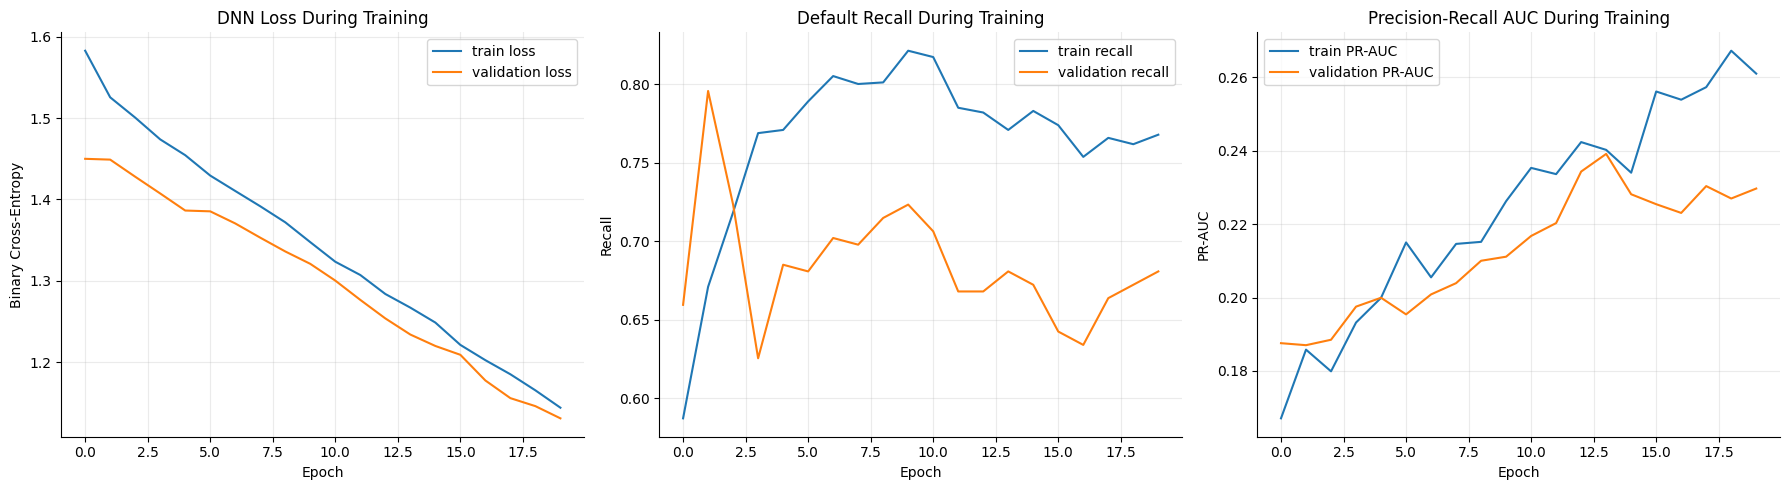

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["loss"], label="train loss")
axes[0].plot(history_df["val_loss"], label="validation loss")
axes[0].set_title("DNN Loss During Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(history_df["recall"], label="train recall")
axes[1].plot(history_df["val_recall"], label="validation recall")
axes[1].set_title("Default Recall During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].legend()

axes[2].plot(history_df["pr_auc"], label="train PR-AUC")
axes[2].plot(history_df["val_pr_auc"], label="validation PR-AUC")
axes[2].set_title("Precision-Recall AUC During Training")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("PR-AUC")
axes[2].legend()

plt.tight_layout()
plt.savefig(MODEL_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.9 Evaluate the DNN on the Test Set

This cell evaluates the trained model on the untouched test set. We calculate probability predictions, convert them to class labels using the default 0.50 threshold, and report the key classification metrics.

In [41]:
y_test_probability = dnn_model.predict(X_test_nn).ravel()
y_test_prediction = (y_test_probability >= DECISION_THRESHOLD).astype(int)

test_metrics = {
    "threshold": DECISION_THRESHOLD,
    "accuracy": accuracy_score(y_test_nn, y_test_prediction),
    "precision": precision_score(y_test_nn, y_test_prediction, zero_division=0),
    "recall": recall_score(y_test_nn, y_test_prediction, zero_division=0),
    "f1": f1_score(y_test_nn, y_test_prediction, zero_division=0),
    "roc_auc": roc_auc_score(y_test_nn, y_test_probability),
}

test_metrics_df = pd.DataFrame([test_metrics]).round(4)
test_metrics_df.to_csv(MODEL_DIR / "test_metrics.csv", index=False)
test_metrics_df

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.5,0.3288,0.1622,0.7655,0.2677,0.5159


### 5.10 Inspect the Confusion Matrix and Classification Report

This cell shows where the model is making mistakes: false positives and false negatives. For loan default prediction, recall for class `1` is especially important because missed defaults are costly.

In [42]:
confusion = confusion_matrix(y_test_nn, y_test_prediction)
confusion_df = pd.DataFrame(
    confusion,
    index=["Actual fully paid", "Actual not fully paid"],
    columns=["Predicted fully paid", "Predicted not fully paid"],
)
confusion_df.to_csv(MODEL_DIR / "confusion_matrix.csv")

print(classification_report(y_test_nn, y_test_prediction, target_names=["Fully paid", "Not fully paid"]))
confusion_df

                precision    recall  f1-score   support

    Fully paid       0.85      0.25      0.38      1609
Not fully paid       0.16      0.77      0.27       307

      accuracy                           0.33      1916
     macro avg       0.50      0.51      0.32      1916
  weighted avg       0.74      0.33      0.36      1916



,Predicted fully paid,Predicted not fully paid
Actual fully paid,395,1214
Actual not fully paid,72,235


### 5.11 Save Predictions and the Trained Model

This cell saves test-set probabilities, predicted classes, and the trained Keras model. These artifacts let us inspect individual predictions and reuse the baseline model later.

In [43]:
predictions_df = pd.DataFrame(
    {
        "actual": y_test_nn,
        "predicted_probability": y_test_probability,
        "predicted_class": y_test_prediction,
    }
)
predictions_df.to_csv(MODEL_DIR / "test_predictions.csv", index=False)

dnn_model.save(MODEL_DIR / "dnn_baseline_model.keras")

print(f"DNN model and evaluation files saved to: {MODEL_DIR.resolve()}")
predictions_df.head()

DNN model and evaluation files saved to: /content/reports/step_05_dnn_baseline


,actual,predicted_probability,predicted_class
0,0,0.721227,1
1,0,0.490626,0
2,0,0.510560,1
3,0,0.501925,1
4,1,0.506904,1


### 5.12 Step 5 Checklist

Before improving the model, check the validation curves, test ROC-AUC, recall for default loans, and the confusion matrix. The next improvement step should tune the decision threshold and compare whether class weights improved minority-class recall enough.

In [44]:
false_negatives = int(confusion[1, 0])
false_positives = int(confusion[0, 1])
true_positives = int(confusion[1, 1])
true_negatives = int(confusion[0, 0])

dnn_checks = {
    "epochs_ran": len(history_df),
    "best_validation_recall": round(float(history_df["val_recall"].max()), 4),
    "best_validation_pr_auc": round(float(history_df["val_pr_auc"].max()), 4),
    "test_accuracy": round(float(test_metrics["accuracy"]), 4),
    "test_precision": round(float(test_metrics["precision"]), 4),
    "test_recall": round(float(test_metrics["recall"]), 4),
    "test_f1": round(float(test_metrics["f1"]), 4),
    "test_roc_auc": round(float(test_metrics["roc_auc"]), 4),
    "false_negatives_actual_defaulters_predicted_safe": false_negatives,
    "false_positives_safe_loans_predicted_default": false_positives,
}

dnn_checks

{'epochs_ran': 20,
 'best_validation_recall': 0.7957,
 'best_validation_pr_auc': 0.2391,
 'test_accuracy': 0.3288,
 'test_precision': 0.1622,
 'test_recall': 0.7655,
 'test_f1': 0.2677,
 'test_roc_auc': 0.5159,
 'false_negatives_actual_defaulters_predicted_safe': 72,
 'false_positives_safe_loans_predicted_default': 1214}

## Step 6: Recall-Focused Fine Tuning and Final Evaluation

This final modeling step makes the loan-default objective explicit: reduce the chance that an actual defaulter is predicted as safe. We train a stable DNN with a stratified validation set, then tune the decision threshold on validation predictions to favor recall while still reporting precision, F1, F2, ROC-AUC, and false negatives.

### 6.1 Configure Recall-Focused Fine Tuning

This cell sets the validation split, recall-focused threshold rules, and output folder. `F2` gives recall more importance than precision, which matches the loan-risk objective.

In [45]:
FINAL_MODEL_DIR = Path("reports/step_06_recall_focused_final_model")
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_VALIDATION_SIZE = 0.20
FINAL_EPOCHS = 180
FINAL_BATCH_SIZE = 64
FINAL_LEARNING_RATE = 0.0006
FINAL_POSITIVE_CLASS_WEIGHT_MULTIPLIER = 1.40
MIN_VALIDATION_PRECISION = 0.20
THRESHOLD_VALUES = np.round(np.arange(0.05, 0.951, 0.01), 2)

### 6.2 Create a Stratified Train-Validation Split

This cell creates a dedicated validation set from the training data. We tune the threshold on validation data only, then evaluate the selected threshold once on the untouched test set.

In [46]:
X_train_fit, X_validation, y_train_fit, y_validation = train_test_split(
    X_train_scaled,
    y_train,
    test_size=FINAL_VALIDATION_SIZE,
    random_state=DNN_RANDOM_STATE,
    stratify=y_train,
)

X_train_fit_nn = X_train_fit.to_numpy(dtype="float32")
X_validation_nn = X_validation.to_numpy(dtype="float32")
y_train_fit_nn = y_train_fit.to_numpy(dtype="int32")
y_validation_nn = y_validation.to_numpy(dtype="int32")

validation_split_summary = pd.DataFrame(
    {
        "dataset": ["train_fit", "validation", "test"],
        "rows": [len(y_train_fit), len(y_validation), len(y_test)],
        "default_count": [int(y_train_fit.sum()), int(y_validation.sum()), int(y_test.sum())],
        "default_rate_pct": [
            round(float(y_train_fit.mean() * 100), 2),
            round(float(y_validation.mean() * 100), 2),
            round(float(y_test.mean() * 100), 2),
        ],
    }
)

validation_split_summary.to_csv(FINAL_MODEL_DIR / "validation_split_summary.csv", index=False)
validation_split_summary

,dataset,rows,default_count,default_rate_pct
0,train_fit,6129,981,16.01
1,validation,1533,245,15.98
2,test,1916,307,16.02


### 6.3 Train the Recall-Focused Final DNN

This cell trains a fresh copy of the deep neural network with stronger positive-class weighting. The callbacks improve stability by reducing the learning rate when validation loss stalls and stopping when validation recall no longer improves.

In [47]:
final_classes = np.array([0, 1])
final_class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=final_classes,
    y=y_train_fit_nn,
)
final_class_weight = {
    int(label): float(weight) for label, weight in zip(final_classes, final_class_weights_array)
}
final_class_weight[1] = final_class_weight[1] * FINAL_POSITIVE_CLASS_WEIGHT_MULTIPLIER

final_dnn_model = build_dnn_model(input_dim, learning_rate=FINAL_LEARNING_RATE)

final_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_recall",
    mode="max",
    patience=22,
    restore_best_weights=True,
)

final_reduce_learning_rate = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=0.00003,
    verbose=1,
)

final_history = final_dnn_model.fit(
    X_train_fit_nn,
    y_train_fit_nn,
    epochs=FINAL_EPOCHS,
    batch_size=FINAL_BATCH_SIZE,
    validation_data=(X_validation_nn, y_validation_nn),
    class_weight=final_class_weight,
    callbacks=[final_early_stopping, final_reduce_learning_rate],
    verbose=1,
)

final_history_df = pd.DataFrame(final_history.history)
final_history_df.to_csv(FINAL_MODEL_DIR / "final_training_history.csv", index=False)
final_history_df.tail()

Epoch 1/180
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 213ms/step - accuracy: 0.4885 - auc: 0.5018 - loss: 1.8346 - pr_auc: 0.1686 - precision: 0.1557 - recall: 0.4964 - val_accuracy: 0.4031 - val_auc: 0.5592 - val_loss: 1.5652 - val_pr_auc: 0.1852 - val_precision: 0.1773 - val_recall: 0.7510 - learning_rate: 6.0000e-04
Epoch 2/180
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4750 - auc: 0.5301 - loss: 1.6705 - pr_auc: 0.1760 - precision: 0.1690 - recall: 0.5821 - val_accuracy: 0.3483 - val_auc: 0.5712 - val_loss: 1.5911 - val_pr_auc: 0.1942 - val_precision: 0.1716 - val_recall: 0.8041 - learning_rate: 6.0000e-04
Epoch 3/180
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4616 - auc: 0.5558 - loss: 1.5854 - pr_auc: 0.1906 - precision: 0.1787 - recall: 0.6575 - val_accuracy: 0.3138 - val_auc: 0.5607 - val_loss: 1.6362 - val_pr_auc: 0.1929 - val_precision: 0.1674 - val_recall: 0.8286 - learning_rate: 6.0000e-04
Epoch 4/180
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4113 - au

,accuracy,auc,loss,pr_auc,precision,recall,val_accuracy,val_auc,val_loss,val_pr_auc,val_precision,val_recall,learning_rate
30,0.440202,0.658057,1.169011,0.262906,0.199608,0.829766,0.407045,0.618947,1.191905,0.220288,0.187382,0.812245,0.0006
31,0.445097,0.660900,1.156809,0.259841,0.199901,0.821611,0.404436,0.622108,1.179776,0.221233,0.183712,0.791837,0.0006
32,0.452929,0.658518,1.145912,0.264097,0.200807,0.811417,0.412916,0.618966,1.169197,0.215901,0.186002,0.791837,0.0006
33,0.455539,0.659606,1.134803,0.258082,0.202975,0.820591,0.412916,0.621332,1.165187,0.212982,0.187798,0.804082,0.0006
34,0.463045,0.669734,1.118659,0.269101,0.205807,0.823649,0.420744,0.604654,1.132812,0.220679,0.186341,0.779592,0.0006


### 6.4 Tune the Decision Threshold for Recall

This cell searches thresholds from 0.05 to 0.95. We first keep thresholds that meet a minimum validation precision, then choose the threshold with the fewest validation false negatives. This directly targets the risky case: actual defaulters predicted as safe.

In [48]:
def evaluate_thresholds(y_true: np.ndarray, probabilities: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
        tn, fp, fn, tp = matrix.ravel()
        precision = precision_score(y_true, predictions, zero_division=0)
        recall = recall_score(y_true, predictions, zero_division=0)
        f1 = f1_score(y_true, predictions, zero_division=0)
        f2 = (5 * precision * recall / ((4 * precision) + recall)) if (precision + recall) > 0 else 0
        rows.append(
            {
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "f2": f2,
                "false_negatives": int(fn),
                "false_positives": int(fp),
                "true_positives": int(tp),
                "true_negatives": int(tn),
                "predicted_default_rate_pct": float(predictions.mean() * 100),
            }
        )
    return pd.DataFrame(rows)


validation_probability = final_dnn_model.predict(X_validation_nn).ravel()
threshold_tuning = evaluate_thresholds(y_validation_nn, validation_probability, THRESHOLD_VALUES)

eligible_thresholds = threshold_tuning[threshold_tuning["precision"] >= MIN_VALIDATION_PRECISION].copy()
if eligible_thresholds.empty:
    eligible_thresholds = threshold_tuning.copy()

selected_threshold_row = eligible_thresholds.sort_values(
    ["false_negatives", "f2", "recall", "precision"],
    ascending=[True, False, False, False],
).iloc[0]
SELECTED_THRESHOLD = float(selected_threshold_row["threshold"])

threshold_tuning.to_csv(FINAL_MODEL_DIR / "threshold_tuning_table.csv", index=False)

print(f"Selected threshold: {SELECTED_THRESHOLD:.2f}")
selected_threshold_row.to_frame().T

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Selected threshold: 0.59


,threshold,precision,recall,f1,f2,false_negatives,false_positives,true_positives,true_negatives,predicted_default_rate_pct
54,0.59,0.209073,0.432653,0.281915,0.356422,139.0,401.0,106.0,887.0,33.072407


### 6.5 Evaluate the Final Model on the Test Set

This cell applies the selected threshold to the untouched test set. The most important number is `false_negatives_actual_defaulters_predicted_safe`, because those are the defaulting borrowers the model would fail to flag.

In [49]:
final_test_probability = final_dnn_model.predict(X_test_nn).ravel()
final_test_prediction = (final_test_probability >= SELECTED_THRESHOLD).astype(int)

final_confusion = confusion_matrix(y_test_nn, final_test_prediction, labels=[0, 1])
final_tn, final_fp, final_fn, final_tp = final_confusion.ravel()

final_precision = precision_score(y_test_nn, final_test_prediction, zero_division=0)
final_recall = recall_score(y_test_nn, final_test_prediction, zero_division=0)
final_f1 = f1_score(y_test_nn, final_test_prediction, zero_division=0)
final_f2 = (
    5 * final_precision * final_recall / ((4 * final_precision) + final_recall)
    if (final_precision + final_recall) > 0
    else 0
)

final_test_metrics = {
    "selected_threshold": SELECTED_THRESHOLD,
    "accuracy": accuracy_score(y_test_nn, final_test_prediction),
    "precision": final_precision,
    "recall": final_recall,
    "f1": final_f1,
    "f2_recall_weighted": final_f2,
    "roc_auc": roc_auc_score(y_test_nn, final_test_probability),
    "false_negatives_actual_defaulters_predicted_safe": int(final_fn),
    "false_positives_safe_loans_predicted_default": int(final_fp),
    "true_positives_defaulters_flagged": int(final_tp),
    "true_negatives_safe_loans_approved": int(final_tn),
}

final_test_metrics_df = pd.DataFrame([final_test_metrics]).round(4)
final_test_metrics_df.to_csv(FINAL_MODEL_DIR / "final_test_metrics.csv", index=False)
final_test_metrics_df

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


,selected_threshold,accuracy,precision,recall,f1,f2_recall_weighted,roc_auc,false_negatives_actual_defaulters_predicted_safe,false_positives_safe_loans_predicted_default,true_positives_defaulters_flagged,true_negatives_safe_loans_approved
0,0.59,0.6628,0.2161,0.4202,0.2854,0.3534,0.5889,178,468,129,1141


### 6.6 Inspect the Final Confusion Matrix

This cell displays the final confusion matrix. In the second row, the left cell is the key risk: actual default loans predicted as fully paid/safe.

In [50]:
final_confusion_df = pd.DataFrame(
    final_confusion,
    index=["Actual fully paid", "Actual not fully paid"],
    columns=["Predicted fully paid", "Predicted not fully paid"],
)
final_confusion_df.to_csv(FINAL_MODEL_DIR / "final_confusion_matrix.csv")

print(classification_report(y_test_nn, final_test_prediction, target_names=["Fully paid", "Not fully paid"]))
final_confusion_df

                precision    recall  f1-score   support

    Fully paid       0.87      0.71      0.78      1609
Not fully paid       0.22      0.42      0.29       307

      accuracy                           0.66      1916
     macro avg       0.54      0.56      0.53      1916
  weighted avg       0.76      0.66      0.70      1916



,Predicted fully paid,Predicted not fully paid
Actual fully paid,1141,468
Actual not fully paid,178,129


### 6.7 Save the Final Model and Predictions

This cell saves the final Keras model and the test-set prediction file. The prediction file includes the probability, selected threshold, predicted class, and whether each row was a false negative.

In [51]:
final_predictions_df = pd.DataFrame(
    {
        "actual": y_test_nn,
        "predicted_probability": final_test_probability,
        "selected_threshold": SELECTED_THRESHOLD,
        "predicted_class": final_test_prediction,
    }
)
final_predictions_df["is_false_negative_defaulter_predicted_safe"] = (
    (final_predictions_df["actual"] == 1) & (final_predictions_df["predicted_class"] == 0)
).astype(int)

final_predictions_df.to_csv(FINAL_MODEL_DIR / "final_test_predictions.csv", index=False)
final_dnn_model.save(FINAL_MODEL_DIR / "final_recall_focused_dnn_model.keras")

print(f"Final model artifacts saved to: {FINAL_MODEL_DIR.resolve()}")
final_predictions_df.head()

Final model artifacts saved to: /content/reports/step_06_recall_focused_final_model


,actual,predicted_probability,selected_threshold,predicted_class,is_false_negative_defaulter_predicted_safe
0,0,0.541786,0.59,0,0
1,0,0.472140,0.59,0,0
2,0,0.553200,0.59,0,0
3,0,0.591039,0.59,1,0
4,1,0.593638,0.59,1,0


### 6.8 Final Project Summary

This project built an end-to-end Lending Club loan default prediction workflow. We loaded the dataset from GitHub, completed EDA, engineered model-ready features, performed leakage-safe train-test splitting and scaling, built a deep neural network with the requested architecture, handled class imbalance, and tuned the final decision threshold to prioritize default recall. The final model is designed to reduce the risky case where an actual defaulter is predicted as safe for loan approval.

In [52]:
project_completion_summary = {
    "project_status": "Complete first-pass recall-focused DNN workflow",
    "final_model_architecture": "6 -> 12 -> 24 -> 64 -> 128 -> 256 -> 128 -> 64 -> 32 -> 8 -> 4 -> 1",
    "primary_business_goal": "Minimize actual defaulters predicted as safe by improving class-1 recall",
    "selected_threshold": round(float(SELECTED_THRESHOLD), 4),
    "final_test_recall": round(float(final_test_metrics["recall"]), 4),
    "final_test_precision": round(float(final_test_metrics["precision"]), 4),
    "final_test_f2": round(float(final_test_metrics["f2_recall_weighted"]), 4),
    "final_test_roc_auc": round(float(final_test_metrics["roc_auc"]), 4),
    "false_negatives_actual_defaulters_predicted_safe": int(final_test_metrics["false_negatives_actual_defaulters_predicted_safe"]),
    "artifacts_folder": str(FINAL_MODEL_DIR.resolve()),
}

project_completion_summary

{'project_status': 'Complete first-pass recall-focused DNN workflow',
 'final_model_architecture': '6 -> 12 -> 24 -> 64 -> 128 -> 256 -> 128 -> 64 -> 32 -> 8 -> 4 -> 1',
 'primary_business_goal': 'Minimize actual defaulters predicted as safe by improving class-1 recall',
 'selected_threshold': 0.59,
 'final_test_recall': 0.4202,
 'final_test_precision': 0.2161,
 'final_test_f2': 0.3534,
 'final_test_roc_auc': 0.5889,
 'false_negatives_actual_defaulters_predicted_safe': 178,
 'artifacts_folder': '/content/reports/step_06_recall_focused_final_model'}